In [6]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from tqdm import tqdm

In [4]:
df_instantaneous_features=pd.read_parquet('../data_parquet/thermo_subsampled_daily.parquet')
df_omni_indices=pd.read_csv('../data/omniweb_data/merged_omni_indices.csv')
df_omni_magnetic_field=pd.read_parquet('../data_parquet/merged_omni_magnetic_field.parquet')
df_omni_solar_wind=pd.read_parquet('../data_parquet/merged_omni_solar_wind.parquet')
df_nrlmsise00_time_series=pd.read_csv('../data_parquet/nrlmsise00_time_series.csv')
df_soho = pd.read_parquet('../data_parquet/soho_data.parquet')

index
0       10990.93
1       10990.93
2       10990.93
3       10990.93
4       10990.93
          ...   
5754    23551.99
5755    23551.99
5756    23551.99
5757    23551.99
5758    23551.99
Name: soho__irradiance_25nm__[W/m2], Length: 113670714, dtype: float64

Processing new dataframe


  0%|          | 0/10 [00:00<?, ?it/s]

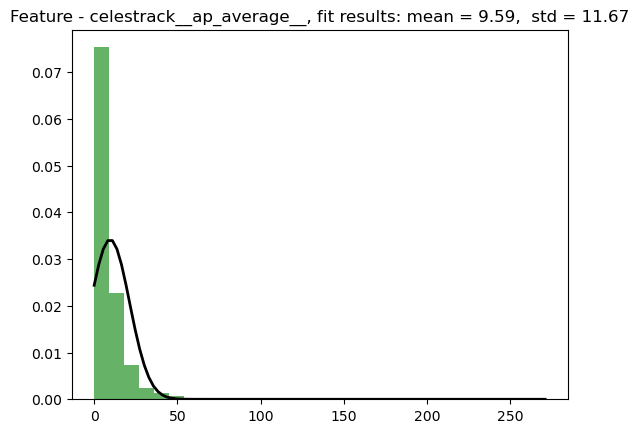

 10%|█         | 1/10 [00:00<00:02,  4.47it/s]

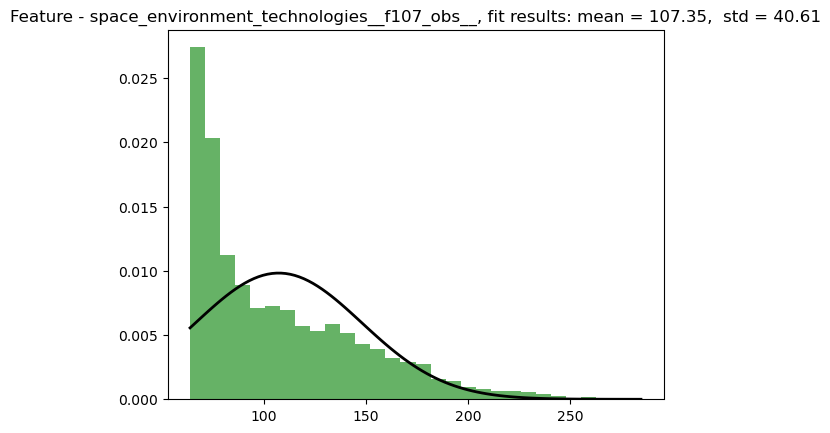

 20%|██        | 2/10 [00:00<00:01,  4.88it/s]

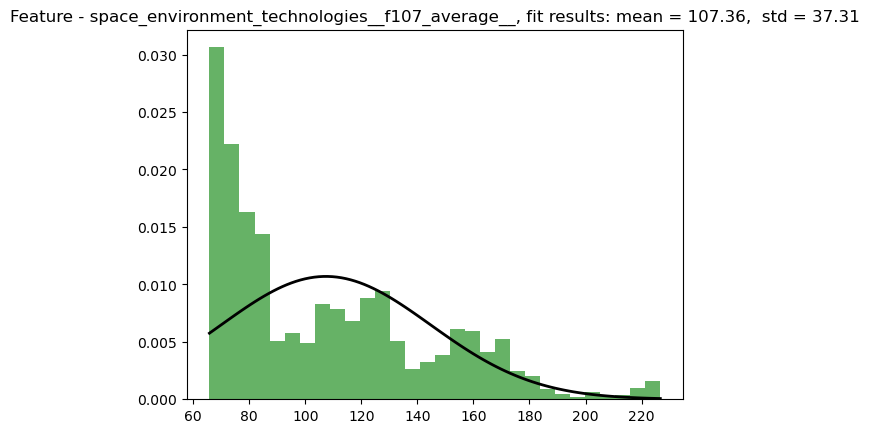

 30%|███       | 3/10 [00:00<00:01,  4.69it/s]

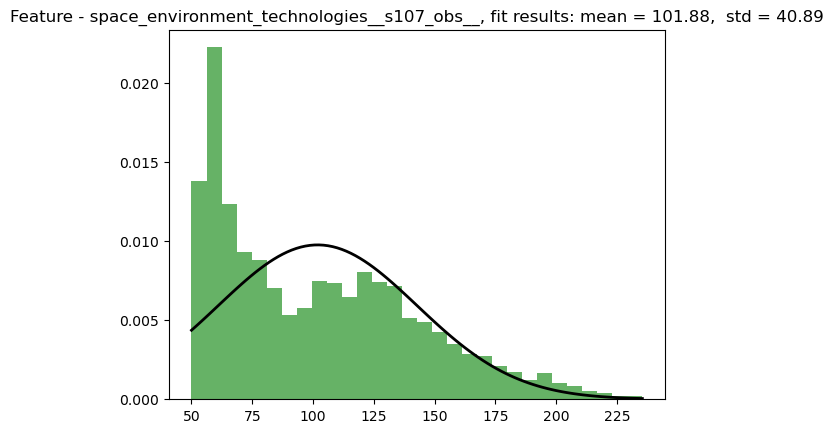

 40%|████      | 4/10 [00:00<00:01,  4.36it/s]

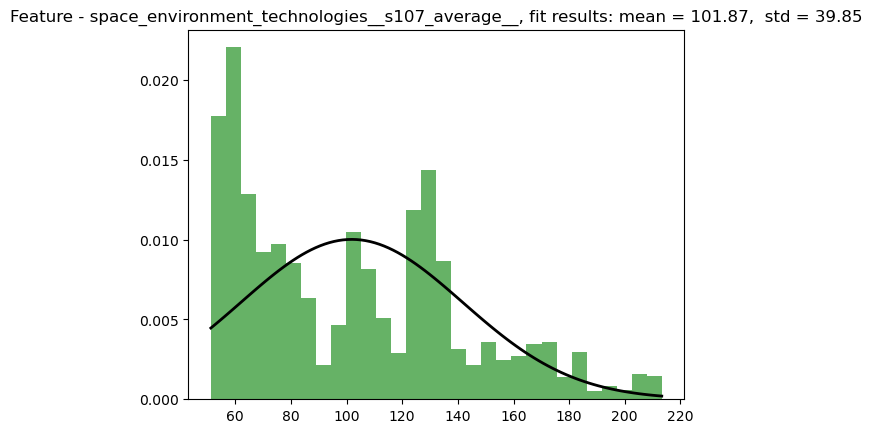

 50%|█████     | 5/10 [00:01<00:01,  4.52it/s]

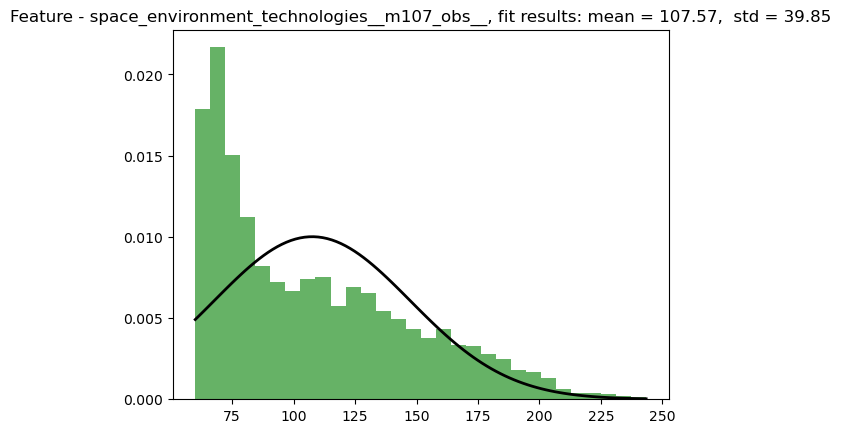

 60%|██████    | 6/10 [00:01<00:00,  4.32it/s]

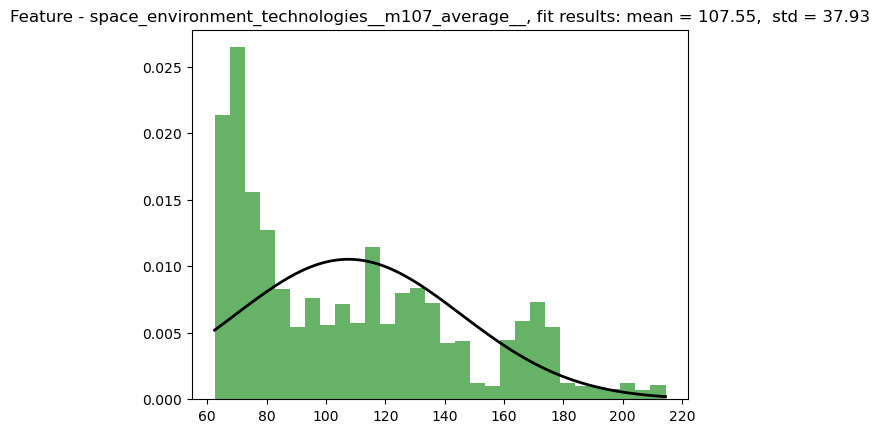

 70%|███████   | 7/10 [00:01<00:00,  4.55it/s]

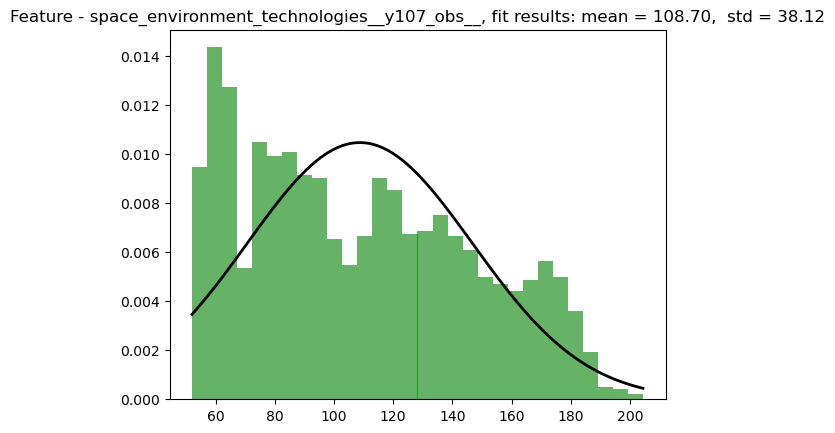

 80%|████████  | 8/10 [00:01<00:00,  4.45it/s]

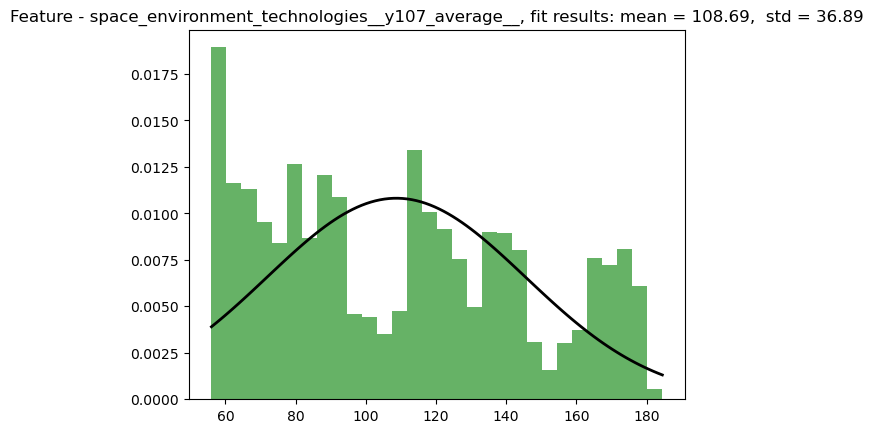

 90%|█████████ | 9/10 [00:01<00:00,  4.53it/s]

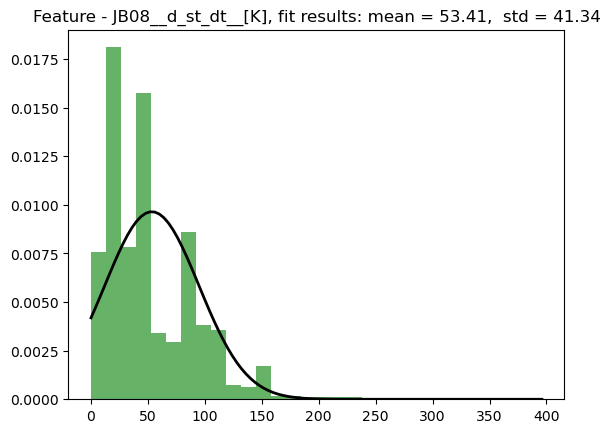

100%|██████████| 10/10 [00:02<00:00,  4.45it/s]


Processing new dataframe


  0%|          | 0/8 [00:00<?, ?it/s]

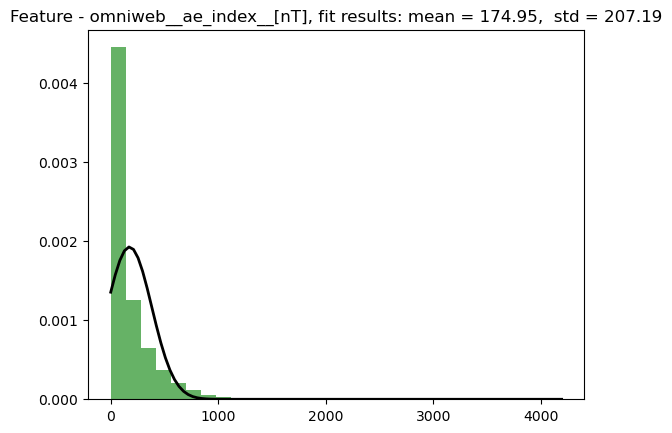

 25%|██▌       | 2/8 [00:00<00:02,  2.11it/s]

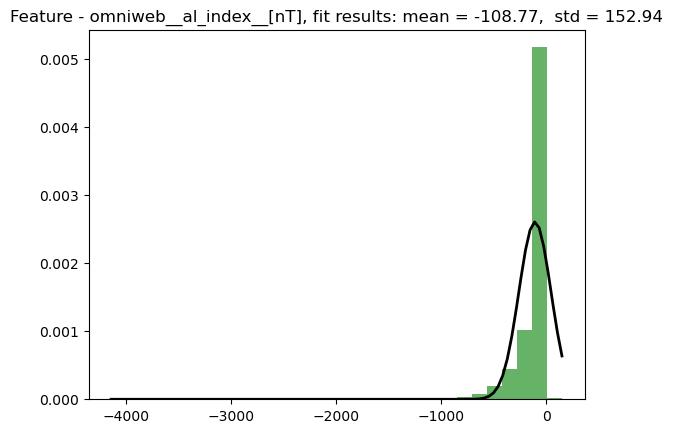

 38%|███▊      | 3/8 [00:01<00:03,  1.64it/s]

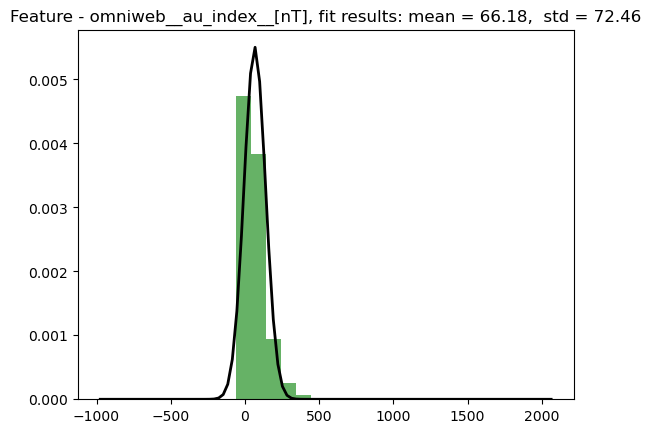

 50%|█████     | 4/8 [00:02<00:02,  1.50it/s]

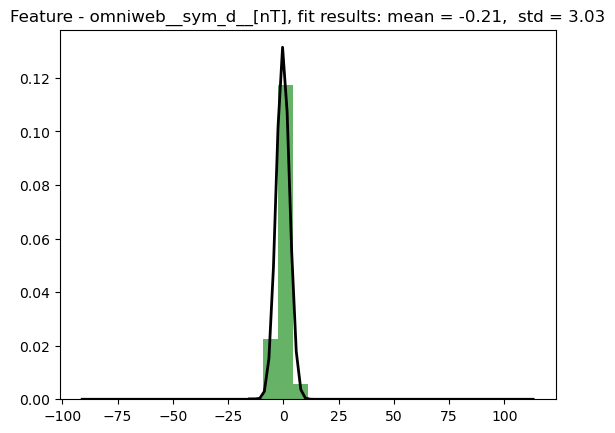

 62%|██████▎   | 5/8 [00:03<00:02,  1.36it/s]

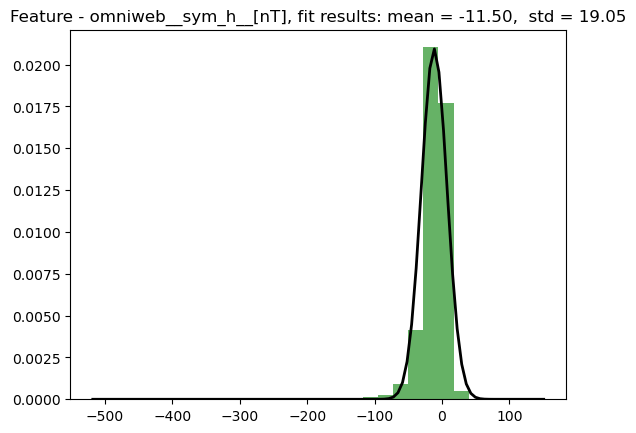

 75%|███████▌  | 6/8 [00:04<00:01,  1.28it/s]

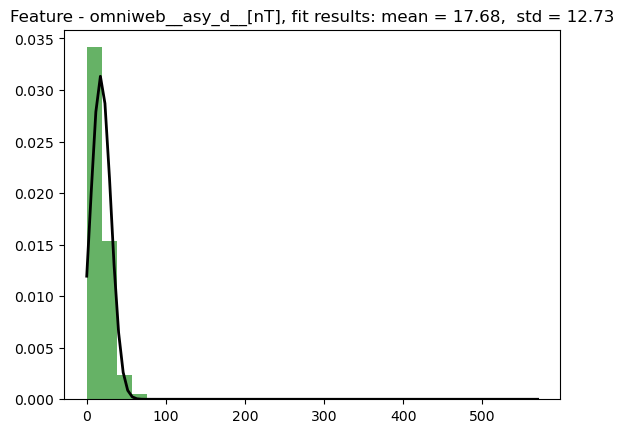

100%|██████████| 8/8 [00:05<00:00,  1.58it/s]


Processing new dataframe


  0%|          | 0/5 [00:00<?, ?it/s]

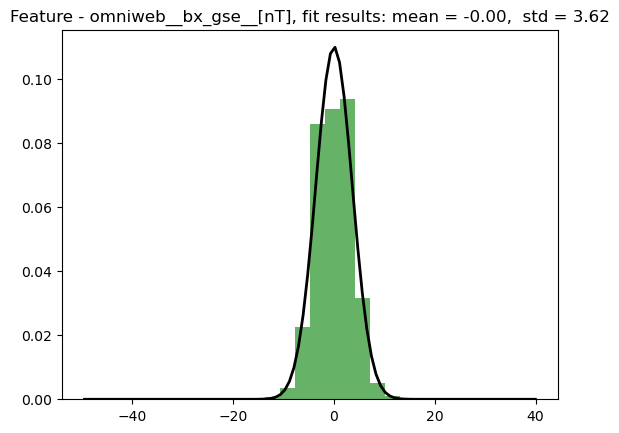

 40%|████      | 2/5 [00:09<00:13,  4.59s/it]

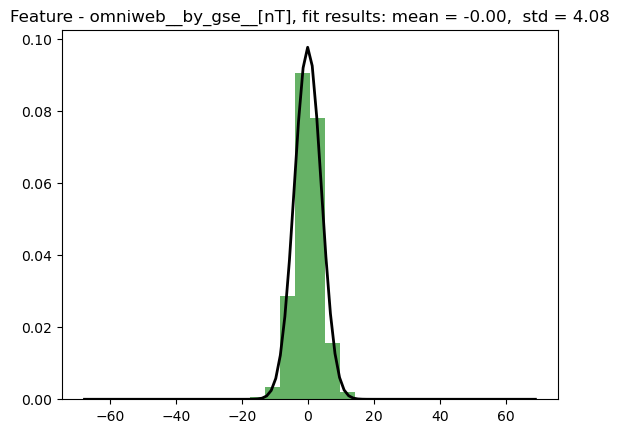

 60%|██████    | 3/5 [00:16<00:11,  5.91s/it]

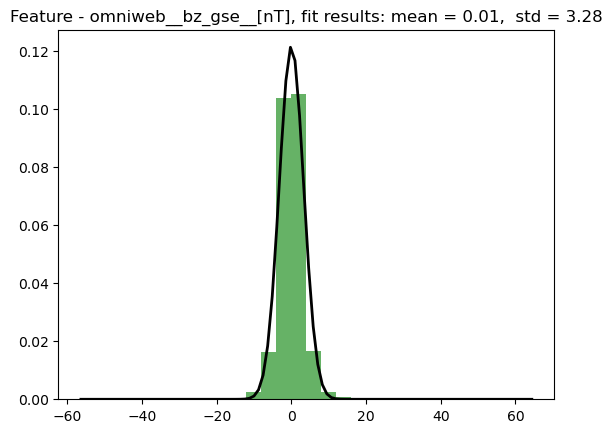

100%|██████████| 5/5 [00:24<00:00,  4.82s/it]


Processing new dataframe


  0%|          | 0/6 [00:00<?, ?it/s]

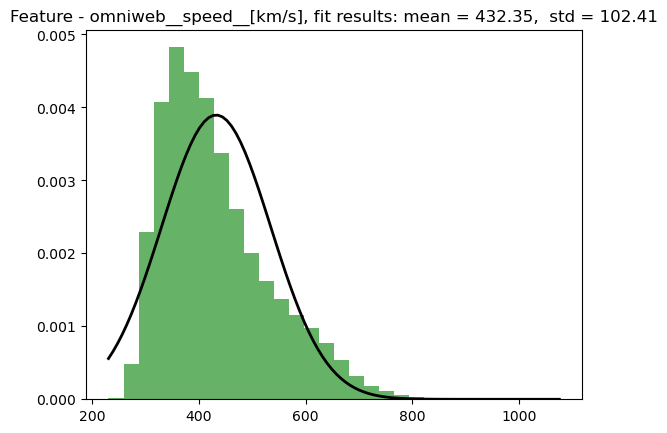

 33%|███▎      | 2/6 [00:07<00:15,  3.80s/it]

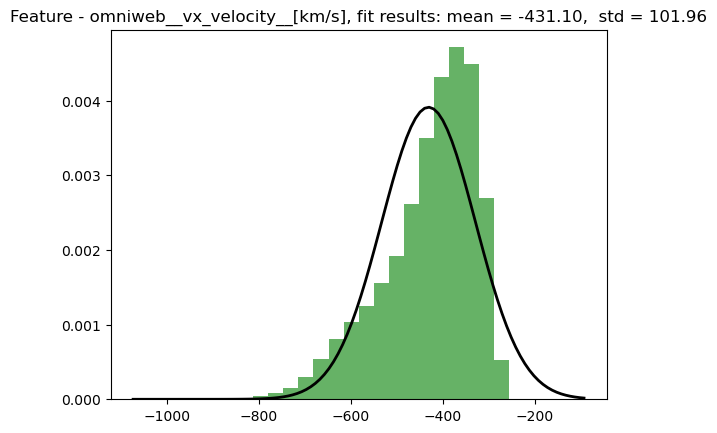

 50%|█████     | 3/6 [00:14<00:15,  5.29s/it]

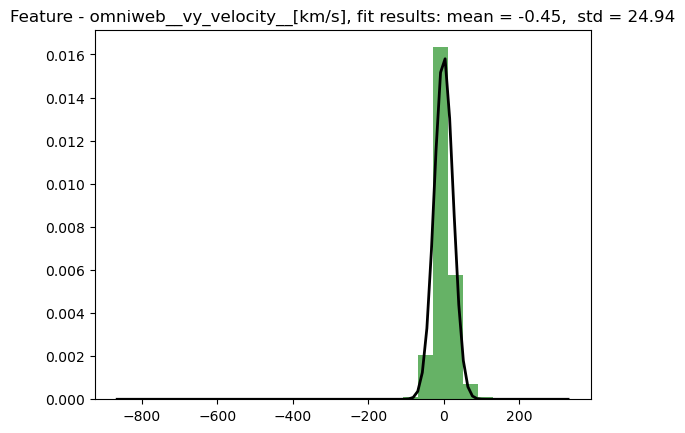

 67%|██████▋   | 4/6 [00:22<00:12,  6.13s/it]

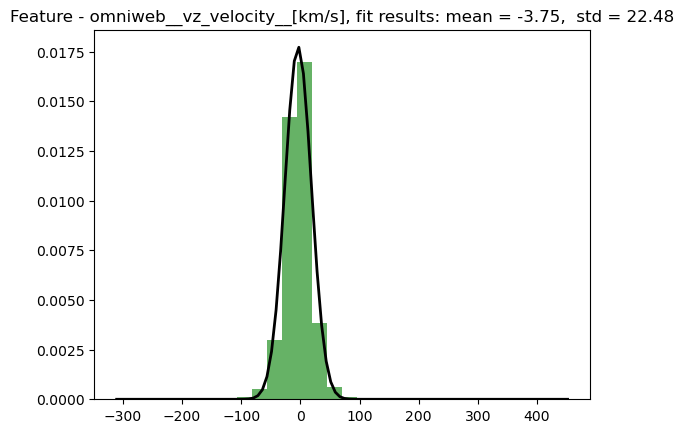

100%|██████████| 6/6 [00:29<00:00,  4.94s/it]


Processing new dataframe


  0%|          | 0/11 [00:00<?, ?it/s]

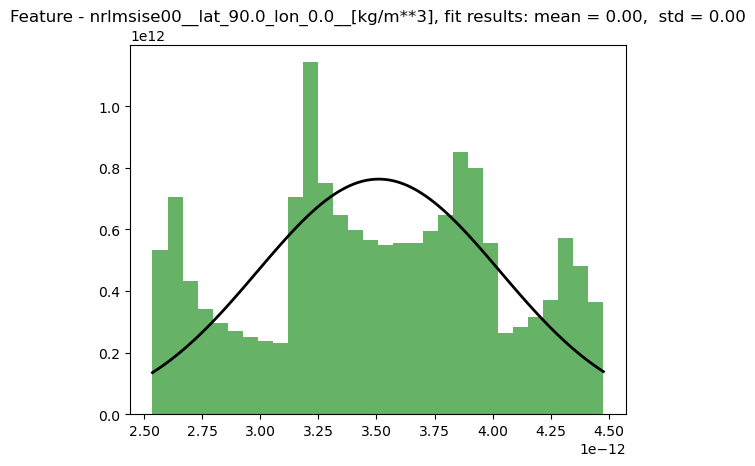

  9%|▉         | 1/11 [00:01<00:11,  1.18s/it]

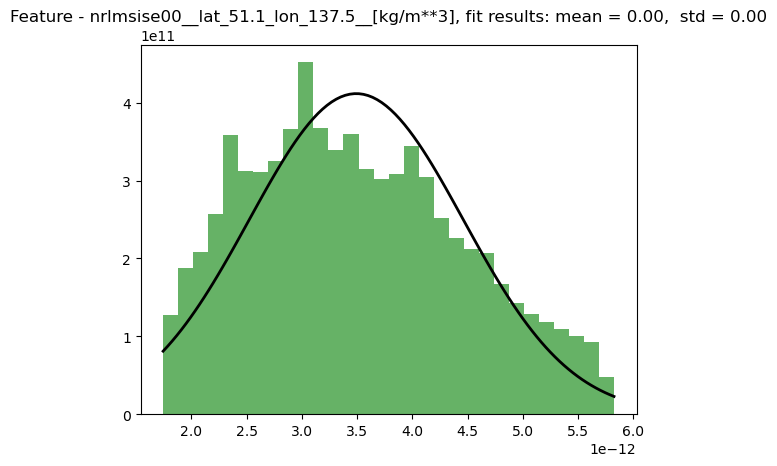

 18%|█▊        | 2/11 [00:02<00:10,  1.17s/it]

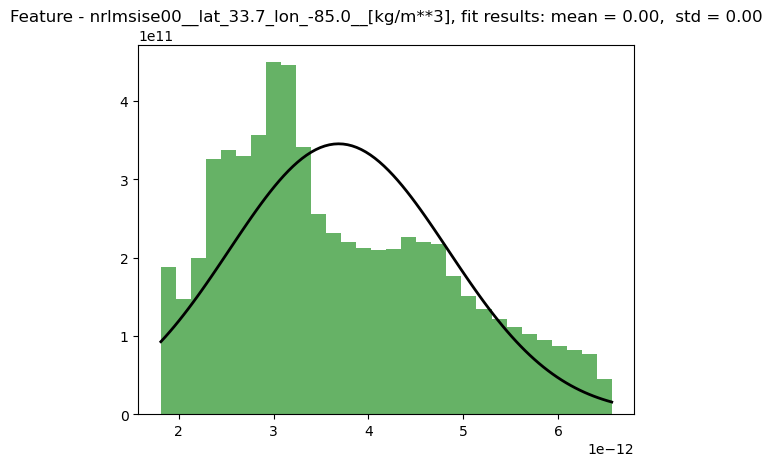

 27%|██▋       | 3/11 [00:03<00:08,  1.11s/it]

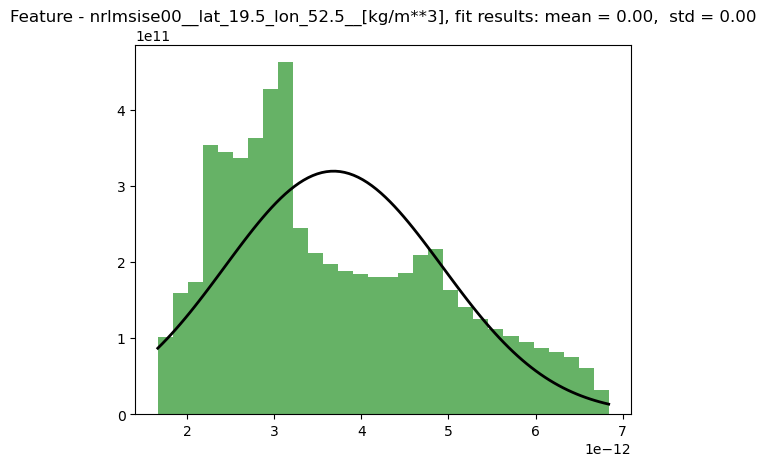

 36%|███▋      | 4/11 [00:04<00:08,  1.16s/it]

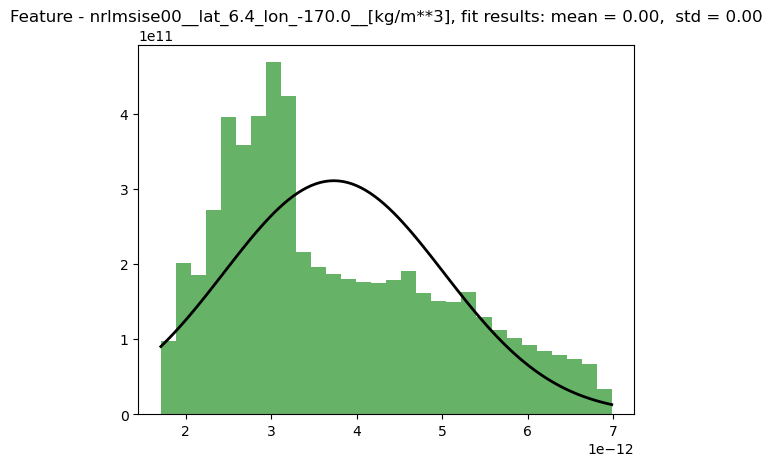

 45%|████▌     | 5/11 [00:05<00:06,  1.15s/it]

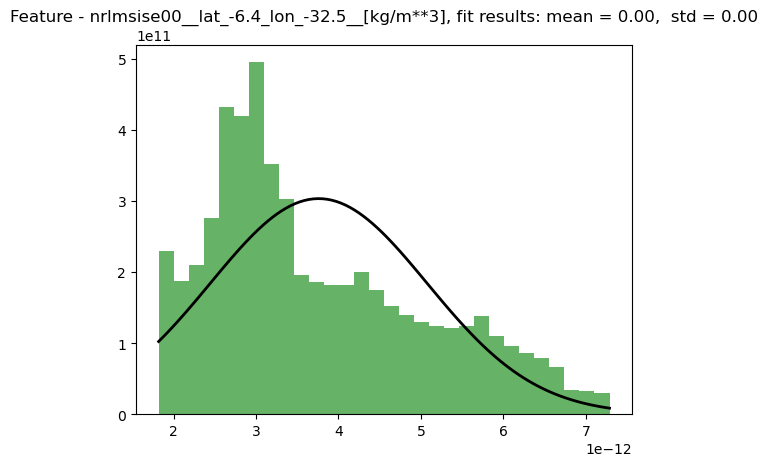

 55%|█████▍    | 6/11 [00:06<00:05,  1.16s/it]

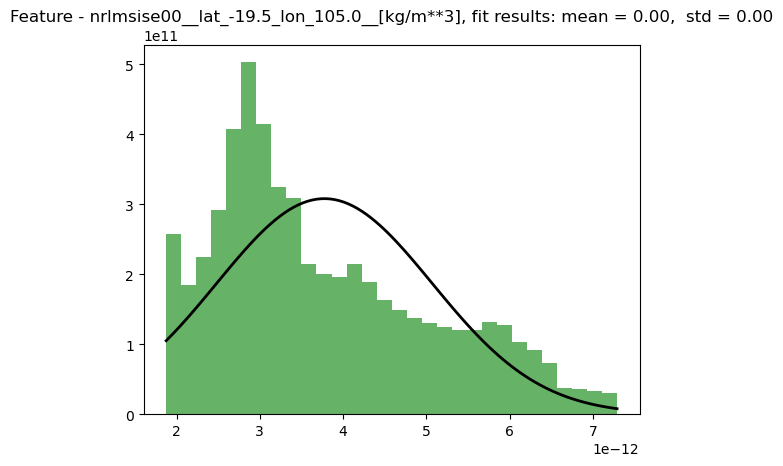

 64%|██████▎   | 7/11 [00:08<00:04,  1.14s/it]

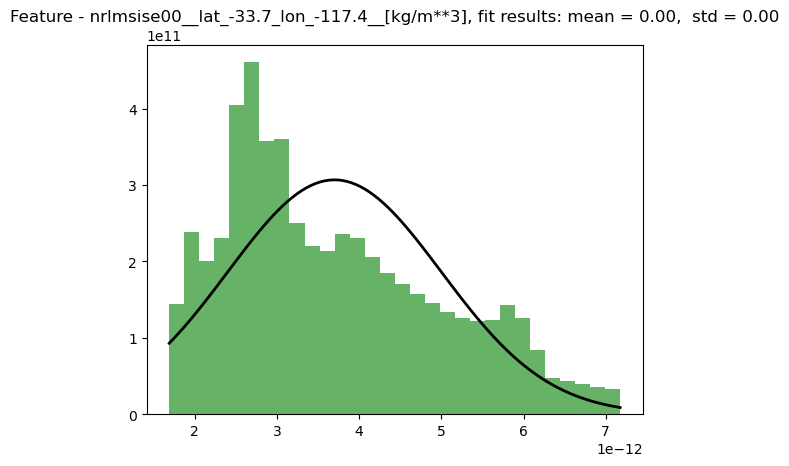

 73%|███████▎  | 8/11 [00:09<00:03,  1.12s/it]

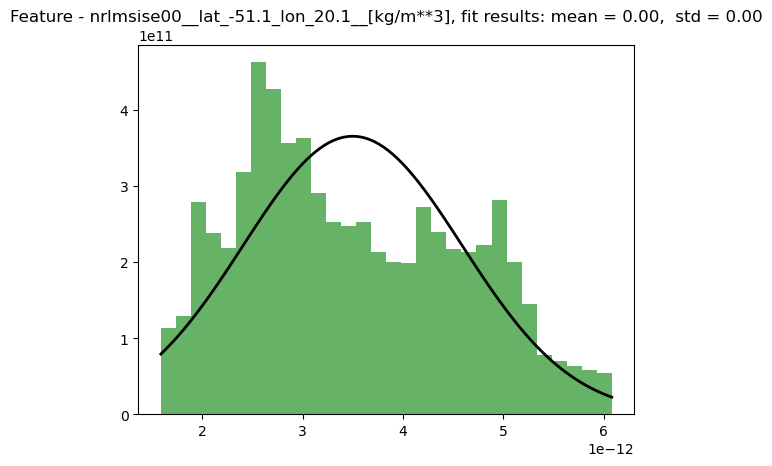

 82%|████████▏ | 9/11 [00:10<00:02,  1.10s/it]

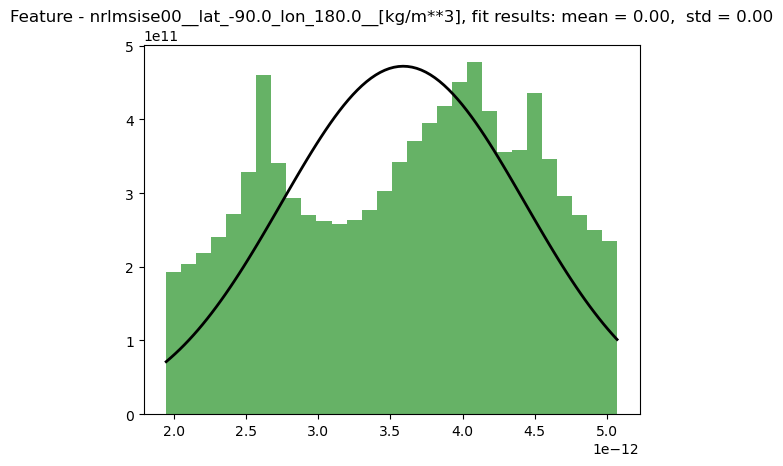

100%|██████████| 11/11 [00:11<00:00,  1.03s/it]


Processing new dataframe


  0%|          | 0/4 [00:00<?, ?it/s]

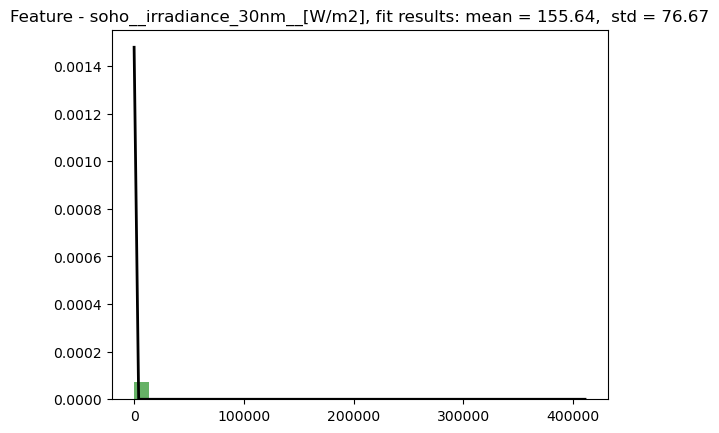

 50%|█████     | 2/4 [00:05<00:05,  2.88s/it]

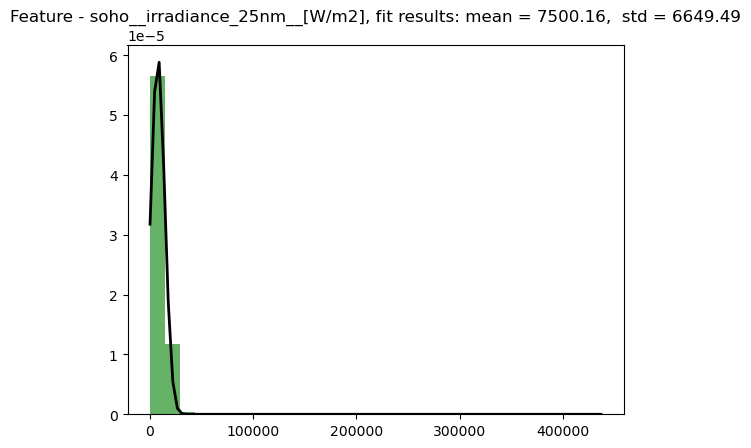

100%|██████████| 4/4 [00:11<00:00,  2.88s/it]


In [16]:
dict_mean_std={}
#let's plot and save them all in a dictionary:
for df in [df_instantaneous_features, df_omni_indices, df_omni_magnetic_field, df_omni_solar_wind, df_nrlmsise00_time_series, df_soho]:
    print('Processing new dataframe')
    for feature in tqdm(df.columns):
        if feature not in ['all__dates_datetime__','source__gaps_flag__']:        
            column_data = df[feature]
            column_data=column_data[~column_data.isna()]
            mean, std = stats.norm.fit(column_data)
            #we save it:
            dict_mean_std[feature+'_mean']=mean
            dict_mean_std[feature+'_std']=std
            #we plot it
            plt.hist(column_data, bins=30, density=True, alpha=0.6, color='g')

            x = np.linspace(column_data.min(), column_data.max(), 100)
            p = stats.norm.pdf(x, mean, std)
            plt.plot(x, p, 'k', linewidth=2)
            title = f"Feature - {feature}, fit results: mean = %.2f,  std = %.2f" % (mean, std)
            plt.title(title)

            plt.show()

In [21]:
sample_value = 30000
#int_[-inf, sample_value] pdf dx:
cumulative_prob = stats.norm.cdf(sample_value, mean, std)  # Cumulative probability
quantile_ninety_nine = stats.norm.ppf(0.99, mean, std)
quantile_zero_zero_1 = stats.norm.ppf(1-0.99, mean, std)

if sample_value > quantile_ninety_nine or sample_value < quantile_zero_zero_1:
    print(f'retrigger with {sample_value}, because cdf is: {cumulative_prob}')

retrigger with 30000, because cdf is: 0.9996424111149514


In [15]:
#with the time series, probably we can do similar things if at least a single row is outside?